# Cross-Encoder Re-Rankers and Query Expansion With An LLM


In [1]:
import torch
from torch.utils.data import DataLoader
from sentence_transformers import util
from sentence_transformers.cross_encoder import CrossEncoder
from sentence_transformers.cross_encoder.evaluation import CERerankingEvaluator
from sentence_transformers import InputExample
from transformers import AutoTokenizer, AutoModelForCausalLM
from datetime import datetime
import gzip, os, tarfile, tqdm, logging
from collections import defaultdict
import numpy as np
import pytrec_eval
import datasets
import matplotlib.pyplot as plt


import os
import json
import sys


logging.basicConfig(format='%(asctime)s - %(message)s', datefmt='%Y-%m-%d %H:%M:%S')
logger = logging.getLogger()
logger.setLevel(logging.INFO)

c:\Users\Matiss\anaconda3\envs\py312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
W0517 11:21:20.434000 22460 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.



## Task 1: Fine-tuning Cross-Encoders

### Hyperparameters

In [2]:
train_batch_size = 32
num_epochs = 1
pos_neg_ratio = 4
max_train_samples = 5e6

# change model_name to switch between the three models:
# 'cross-encoder/ms-marco-MiniLM-L-2-v2'
# 'cross-encoder/ms-marco-TinyBERT-L-2-v2'
# 'distilroberta-base'
model_name = 'cross-encoder/ms-marco-MiniLM-L-2-v2'

# local save path (no Google Drive needed)
model_save_path = 'finetuned_models/cross-encoder-' + model_name.replace('/', '-') + '-' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
os.makedirs(model_save_path, exist_ok=True)
print(f"Will save to: {model_save_path}")


Will save to: finetuned_models/cross-encoder-cross-encoder-ms-marco-MiniLM-L-2-v2-2026-05-17_11-21-42


###  Load model

In [3]:
model = CrossEncoder(model_name, num_labels=1, max_length=512)

2026-05-17 11:21:50 - Use pytorch device: cuda


### Download MS MARCO data and load training samples

In [4]:
data_folder = 'msmarco-data'
os.makedirs(data_folder, exist_ok=True)

# corpus
corpus = {}
collection_filepath = os.path.join(data_folder, 'collection.tsv')
if not os.path.exists(collection_filepath):
    tar_filepath = os.path.join(data_folder, 'collection.tar.gz')
    if not os.path.exists(tar_filepath):
        logging.info("Downloading collection.tar.gz")
        util.http_get('https://msmarco.z22.web.core.windows.net/msmarcoranking/collection.tar.gz', tar_filepath)
    with tarfile.open(tar_filepath, 'r:gz') as tar:
        tar.extractall(path=data_folder)

with open(collection_filepath, 'r', encoding='utf8') as f:
    for line in f:
        pid, passage = line.strip().split('\t')
        corpus[pid] = passage

# queries
queries_train = {}
queries_filepath = 'queries.train.tsv'
if not os.path.exists(queries_filepath):
    util.http_get('https://msmarco.z22.web.core.windows.net/msmarcoranking/queries.tar.gz', 'queries.tar.gz')
    with tarfile.open('queries.tar.gz', 'r:gz') as tar:
        tar.extractall()

with open(queries_filepath, 'r', encoding='utf8') as f:
    for line in f:
        qid, query = line.strip().split('\t')
        queries_train[qid] = query

# train / dev split
train_samples = []
dev_samples = {}
num_dev_queries = 200
num_max_dev_negatives = 200

train_eval_filepath = os.path.join(data_folder, 'msmarco-qidpidtriples.rnd-shuf.train-eval.tsv.gz')
if not os.path.exists(train_eval_filepath):
    util.http_get('https://sbert.net/datasets/msmarco-qidpidtriples.rnd-shuf.train-eval.tsv.gz', train_eval_filepath)

with gzip.open(train_eval_filepath, 'rt') as f:
    for line in f:
        qid, pos_id, neg_id = line.strip().split()
        if qid not in dev_samples and len(dev_samples) < num_dev_queries:
            dev_samples[qid] = {'query': queries_train[qid], 'positive': set(), 'negative': set()}
        if qid in dev_samples:
            dev_samples[qid]['positive'].add(corpus[pos_id])
            if len(dev_samples[qid]['negative']) < num_max_dev_negatives:
                dev_samples[qid]['negative'].add(corpus[neg_id])

train_filepath = os.path.join(data_folder, 'msmarco-qidpidtriples.rnd-shuf.train.tsv.gz')
if not os.path.exists(train_filepath):
    util.http_get('https://sbert.net/datasets/msmarco-qidpidtriples.rnd-shuf.train.tsv.gz', train_filepath)

cnt = 0
with gzip.open(train_filepath, 'rt') as f:
    for line in tqdm.tqdm(f, unit_scale=True):
        qid, pos_id, neg_id = line.strip().split()
        if qid in dev_samples:
            continue
        query = queries_train[qid]
        if (cnt % (pos_neg_ratio + 1)) == 0:
            passage, label = corpus[pos_id], 1
        else:
            passage, label = corpus[neg_id], 0
        train_samples.append(InputExample(texts=[query, passage], label=label))
        cnt += 1
        if cnt >= max_train_samples:
            break

print(f"Train samples: {len(train_samples):,}  |  Dev queries: {len(dev_samples):,}")


5.00Mit [00:20, 243kit/s] 

Train samples: 5,000,000  |  Dev queries: 200


### Train the model
We add automatic keyboard interupt after 1 hour has passed for fair comparison

In [ ]:
# NO NEED TO RETRAIN ======== DO NOT RUN ===========

import time

class TimedTraining:
    """Stops training after max_hours by raising an exception in the callback."""
    def __init__(self, max_hours=1):
        self.deadline = time.time() + max_hours * 3600
    
    def __call__(self, score, epoch, steps):
        if time.time() > self.deadline:
            raise KeyboardInterrupt(f"1h reached at step {steps} — stopping.")

train_dataloader = DataLoader(train_samples, shuffle=True, batch_size=train_batch_size)
evaluator = CERerankingEvaluator(dev_samples, name='train-eval')

try:
    model.fit(
        train_dataloader=train_dataloader,
        evaluator=evaluator,
        epochs=num_epochs,
        evaluation_steps=1000,
        warmup_steps=5000,
        output_path=model_save_path,
        use_amp=True,
        callback=TimedTraining(max_hours=1),
    )
except KeyboardInterrupt as e:
    print(e)

model.save(model_save_path)
print(f"Model saved to {model_save_path}")


c:\Users\Matiss\anaconda3\envs\py312\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:233: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration:   0%|          | 0/156250 [00:00<?, ?it/s]

2026-05-03 17:09:17 - CERerankingEvaluator: Evaluating the model on train-eval dataset in epoch 0 after 1000 steps:
2026-05-03 17:10:22 - Queries: 200 	 Positives: Min 1.0, Mean 1.1, Max 3.0 	 Negatives: Min 100.0, Mean 199.1, Max 200.0
2026-05-03 17:10:22 - MRR@10: 40.84
2026-05-03 17:10:22 - NDCG@10: 47.58
2026-05-03 17:10:22 - Save model to finetuned_models/cross-encoder-distilroberta-base-2026-05-03_17-07-05
2026-05-03 17:11:50 - CERerankingEvaluator: Evaluating the model on train-eval dataset in epoch 0 after 2000 steps:
2026-05-03 17:12:56 - Queries: 200 	 Positives: Min 1.0, Mean 1.1, Max 3.0 	 Negatives: Min 100.0, Mean 199.1, Max 200.0
2026-05-03 17:12:56 - MRR@10: 49.31
2026-05-03 17:12:56 - NDCG@10: 56.12
2026-05-03 17:12:56 - Save model to finetuned_models/cross-encoder-distilroberta-base-2026-05-03_17-07-05
2026-05-03 17:14:24 - CERerankingEvaluator: Evaluating the model on train-eval dataset in epoch 0 after 3000 steps:
2026-05-03 17:15:29 - Queries: 200 	 Positives: Min 

1h reached at step 24000 — stopping.
Model saved to finetuned_models/cross-encoder-distilroberta-base-2026-05-03_17-07-05


: 

: 

### Evaluation on TREC DL'19

Evaluate the fine-tuned model on the 43 TREC DL'19 queries.

In [5]:
# load TREC DL'19 data
DATA_DIR = "Data"

QUERIES_PATH    = os.path.join(DATA_DIR, "queries.tsv")
CANDIDATES_PATH = os.path.join(DATA_DIR, "candidates.tsv")
QRELS_PATH      = os.path.join(DATA_DIR, "qrels.txt")

queries = {}
with open(QUERIES_PATH, 'r') as f:
    for line in f:
        qid, query = line.strip().split('\t')
        queries[qid] = query

candidates = {}
with open(CANDIDATES_PATH, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        qid, docid, doctext = parts[0], parts[1], parts[3]
        if qid not in candidates:
            candidates[qid] = []
        candidates[qid].append((docid, doctext))

qrels = {}
with open(QRELS_PATH, 'r') as f:
    for line in f:
        parts = line.strip().split()
        qid, docid, relevance = parts[0], parts[2], int(parts[3])
        if qid not in qrels:
            qrels[qid] = {}
        qrels[qid][docid] = relevance

# filter to the 43 queries with qrels
qrel_ids = set(qrels.keys())
queries    = {k: v for k, v in queries.items()    if k in qrel_ids}
candidates = {k: v for k, v in candidates.items() if k in qrel_ids}

assert len(queries) == len(candidates) == len(qrels) == 43


After all three models are fine-tuned, we score them here

In [6]:
model_paths = {
    "MiniLM-L2":     "finetuned_models/cross-encoder-cross-encoder-ms-marco-MiniLM-L-2-v2-2026-05-03_14-43-59",
    "TinyBERT-L2":   "finetuned_models/cross-encoder-cross-encoder-ms-marco-TinyBERT-L-2-v2-2026-05-03_16-03-29",
    "DistilRoBERTa": "finetuned_models/cross-encoder-distilroberta-base-2026-05-03_17-07-05",
}

def score_candidates(queries, candidates, cross_encoder, batch_size=32):
    results = {}
    for qid, query_text in tqdm.tqdm(queries.items(), desc="Scoring"):
        docs  = candidates[qid]
        pairs = [(query_text, doc_text) for _, doc_text in docs]
        scores = cross_encoder.predict(pairs, batch_size=batch_size, show_progress_bar=False)
        results[qid] = {docid: float(s) for (docid, _), s in zip(docs, scores)}
    return results

all_scores = {}
for name, path in model_paths.items():
    eval_model = CrossEncoder(path, max_length=512, device='cuda')
    all_scores[name] = score_candidates(queries, candidates, eval_model)
    print(f"Done: {name}")

Scoring: 100%|██████████| 43/43 [00:13<00:00,  3.25it/s]


Done: MiniLM-L2


Scoring: 100%|██████████| 43/43 [00:12<00:00,  3.45it/s]


Done: TinyBERT-L2


Scoring: 100%|██████████| 43/43 [01:02<00:00,  1.45s/it]

Done: DistilRoBERTa


In [7]:
def evaluate(scores, qrels):
    evaluator = pytrec_eval.RelevanceEvaluator(qrels, {'ndcg_cut_10', 'recall_100', 'map_cut_1000'})
    results   = evaluator.evaluate(scores)
    metrics   = {}
    for measure in ['ndcg_cut_10', 'recall_100', 'map_cut_1000']:
        metrics[measure] = round(sum(r[measure] for r in results.values()) / len(results), 4)
    return metrics

print(f"{'Model':<15} {'NDCG@10':>10} {'Recall@100':>12} {'MAP@1000':>10}")
print('-' * 50)

for name, (path, scores) in zip(model_paths.keys(), zip(model_paths.values(), all_scores.values())):
    # save ranking.run for tasks 2 & 3
    run_file = os.path.join(path, 'ranking.run')
    with open(run_file, 'w') as f:
        for qid, pid_scores in scores.items():
            for rank, (pid, score) in enumerate(
                    sorted(pid_scores.items(), key=lambda x: x[1], reverse=True), 1):
                f.write(f"{qid} Q0 {pid} {rank} {score:.6f} cross-encoder\n")

    metrics = evaluate(scores, qrels)
    print(f"{name:<15} {metrics['ndcg_cut_10']:>10} {metrics['recall_100']:>12} {metrics['map_cut_1000']:>10}")

Model              NDCG@10   Recall@100   MAP@1000
--------------------------------------------------
MiniLM-L2           0.6724       0.4985     0.4293
TinyBERT-L2         0.6703       0.4973      0.443
DistilRoBERTa       0.6599       0.4907     0.4227


MiniLM-L2 performs best on NDCG and Recall metrics, whereas TinyBERT-L2 is best in MAP

## Task 2: Five fusion methods



Load the three `ranking.run` files produced above and apply fusion methods using ranx.

In [8]:
from ranx import Qrels, Run, fuse, evaluate as ranx_evaluate

run_paths = {
    "MiniLM-L2":     "finetuned_models/cross-encoder-cross-encoder-ms-marco-MiniLM-L-2-v2-2026-05-03_14-43-59/ranking.run",
    "TinyBERT-L2":   "finetuned_models/cross-encoder-cross-encoder-ms-marco-TinyBERT-L-2-v2-2026-05-03_16-03-29/ranking.run",
    "DistilRoBERTa": "finetuned_models/cross-encoder-distilroberta-base-2026-05-03_17-07-05/ranking.run",
}

ranx_runs  = [Run.from_file(path, kind="trec", name=name) for name, path in run_paths.items()]
ranx_qrels = Qrels.from_file(QRELS_PATH, kind="trec")

In [9]:
# we choose CombSUM, CombMNZ, Reciprocal Rank Fusion (RRF), BordaFuse, and Condorcet
FUSION_METHODS = ['sum', 'mnz', 'rrf', 'bordafuse', 'condorcet']
print(f"{'Method':<15} {'NDCG@10':>10} {'Recall@100':>12} {'MAP@1000':>10}")
print('-' * 50)
for method in FUSION_METHODS:
    fused  = fuse(runs=ranx_runs, method=method)
    scores = ranx_evaluate(ranx_qrels, fused, ['ndcg@10', 'recall@100', 'map@1000']) # use built in ranx evaluation function
    print(f"{method:<15} {scores['ndcg@10']:>10.4f} {scores['recall@100']:>12.4f} {scores['map@1000']:>10.4f}")


Method             NDCG@10   Recall@100   MAP@1000
--------------------------------------------------
sum                 0.6978       0.5095     0.4567
mnz                 0.6978       0.5095     0.4567
rrf                 0.7053       0.5088     0.4600
bordafuse           0.7087       0.5068     0.4597
condorcet           0.6989       0.5099     0.4593


## Task 3: Best method on pairwise model combinations

In [10]:
from itertools import combinations

best_method = 'bordafuse'

print(f"Fusion method: {best_method}")
print(f"{'Combination':<45} {'NDCG@10':>10} {'Recall@100':>12} {'MAP@1000':>10}")
print('-' * 80)

names = list(run_paths.keys())
for (i, run_a), (j, run_b) in combinations(enumerate(ranx_runs), 2):
    label  = f"{names[i]} + {names[j]}"
    fused  = fuse(runs=[run_a, run_b], method=best_method)
    scores = ranx_evaluate(ranx_qrels, fused, ['ndcg@10', 'recall@100', 'map@1000'])
    print(f"{label:<45} {scores['ndcg@10']:>10.4f} {scores['recall@100']:>12.4f} {scores['map@1000']:>10.4f}")


Fusion method: bordafuse
Combination                                      NDCG@10   Recall@100   MAP@1000
--------------------------------------------------------------------------------
MiniLM-L2 + TinyBERT-L2                           0.6872       0.5004     0.4509
MiniLM-L2 + DistilRoBERTa                         0.7012       0.5046     0.4488
TinyBERT-L2 + DistilRoBERTa                       0.6966       0.5044     0.4584


## Task 4: Query Expansion

In [11]:
model_name = "HuggingFaceH4/zephyr-7b-beta"
tokenizer = AutoTokenizer.from_pretrained(model_name, truncation=True, padding=True, padding_side="left", maximum_length=2048, model_max_length=2048)
model = AutoModelForCausalLM.from_pretrained(model_name, load_in_4bit=True, device_map='auto')
tokenizer.pad_token = tokenizer.eos_token
model.generation_config.pad_token_id = model.generation_config.eos_token_id

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
2026-05-17 11:26:55 - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

In [12]:
# first up load the data that is in /Data folder

# define paths
DATA_DIR = "Data"

QUERIES_PATH = os.path.join(DATA_DIR, "queries.tsv")
CANDIDATES_PATH = os.path.join(DATA_DIR, "candidates.tsv")
QRELS_PATH = os.path.join(DATA_DIR, "qrels.txt")

# load queruies
queries = {}
with open(QUERIES_PATH, "r") as f:
    for line in f:
        query_id, query = line.strip().split("\t")
        queries[query_id] = query
        
        
# load candidates
candidates = {}
with open(CANDIDATES_PATH, "r") as f:
    for line in f:
        parts = line.strip().split("\t")
        query_id, docid, doctext = parts[0], parts[1], parts[3] # skip 3rd column, that is query_text
        if query_id not in candidates:
            candidates[query_id] = []
        candidates[query_id].append((docid, doctext))
        

# load qrels
qrels = {}
with open(QRELS_PATH, "r") as f:
    for line in f:
        parts = line.strip().split() # not a tab-separated file (tsv) so regular white space split
        query_id, docid, relevance = parts[0], parts[2], int(parts[3]), # skip 2nd column and relevance in integers
        if query_id not in qrels:
            qrels[query_id] = {}
        qrels[query_id][docid] = relevance
        
# print(f"#queries    {len(queries)}") #200
# print(f"#query ids with candidates {len(candidates)}") # 200
# print(f"#query ids with qrels      {len(qrels)}") # 43

# we will only work with the 43 queries that have qrels, so filter candidates and queries to those
qrel_query_ids = set(qrels.keys())
queries = {query_id: query_text for query_id, query_text in queries.items() if query_id in qrel_query_ids}
candidates = {query_id: docs for query_id, docs in candidates.items() if query_id in qrel_query_ids}


 # check
assert len(queries) == 43
assert len(candidates) == 43
assert len(qrels) == 43
sample_query_id = list(queries.keys())[0]
print(f"\nsample query [{sample_query_id}]: {queries[sample_query_id]}")
print(f"{len(candidates[sample_query_id])} candidate docs")
print(f"{len(qrels.get(sample_query_id, {}))} qrel judgements")


sample query [156493]: do goldfish grow
1000 candidate docs
300 qrel judgements


In [13]:
# query expansion pipeline
# we build the CoT pipeline for each query and run it through the LLM

def build_cot_prompt(query):
    return f"Answer the following query:\n{query}\nGive the rationale before answering" 


def generate_expansions(queries, model, tokenizer, max_new_tokens=200, batch_size=4, prompt_fn=build_cot_prompt):
    expanded_queries = {}
    query_ids = list(queries.keys())
    
    for i in tqdm.tqdm(range(0, len(query_ids), batch_size), desc="Expanding queries"):
        batch_ids = query_ids[i: i + batch_size]
        batch_prompts = [prompt_fn(queries[query_id]) for query_id in batch_ids]
        
        # tokenization
        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True, max_length=512).to(model.device)
        
        # generate
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, temperature=1.0, repetition_penalty=1.1)
            
        # decode new tokens not the prompt here
        for j, query_id in enumerate(batch_ids):
            input_len = inputs["input_ids"].shape[1]
            new_tokens = outputs[j][input_len:]
            expansion = tokenizer.decode(new_tokens, skip_special_tokens=True)
            
            # in paper they have closing phrashes to filter out from CoT output
            expansion = expansion.replace("The final answer:", "").strip()
            expansion = expansion.replace("So the final answer is:", "").strip()
            
            # concatenate orinigal query + LLM output but no 5x repetition
            expanded_queries[query_id] = queries[query_id] + " " + expansion

    return expanded_queries 

In [14]:
# run
expanded_queries = generate_expansions(queries, model, tokenizer)

#check
sample_query_id = list(expanded_queries.keys())[0] # grab fresh one after the filtering
print(f"original:  {queries[sample_query_id]}")
print(f"\nexpanded:  {expanded_queries[sample_query_id]}")

Expanding queries: 100%|██████████| 11/11 [09:13<00:00, 50.28s/it]

original:  do goldfish grow

expanded:  do goldfish grow .

Answer: Yes, goldfish do grow throughout their lives. Goldfish are known to continue growing as long as they live in good conditions with proper nutrition and care. The growth rate of a goldfish may slow down as it reaches maturity, but it will not stop growing entirely. This is because goldfish have an indeterminate growth pattern, meaning they do not reach a fixed size like some other fish species. Instead, they continue to grow based on environmental factors such as food availability, water quality, and genetics. Therefore, it's essential to provide your goldfish with a suitable environment that supports healthy growth while avoiding overfeeding, which can lead to obesity and related health issues.


### We have the query, now to pass it to the Cross encoder for re-ranking

In [15]:
# loading fine-tuned model from Task 1
from sentence_transformers import CrossEncoder

CROSS_ENCODER_MODEL = "finetuned_models/cross-encoder-cross-encoder-ms-marco-MiniLM-L-2-v2-2026-05-03_14-43-59"
cross_encoder = CrossEncoder(CROSS_ENCODER_MODEL, max_length=512, device="cuda")
print(f"loaded: {CROSS_ENCODER_MODEL}")

loaded: finetuned_models/cross-encoder-cross-encoder-ms-marco-MiniLM-L-2-v2-2026-05-03_14-43-59


In [16]:
# scoring
def score_candidates(queries, candidates, cross_encoder, batch_size=32):
    
    results = {}
    
    for query_id, query_text in tqdm.tqdm(queries.items(), desc="Scoring"):
        docs = candidates[query_id]
        
        pairs = [(query_text, doc_text) for doc_id, doc_text in docs] # build query-docs pairs
        scores = cross_encoder.predict(pairs, batch_size=batch_size, show_progress_bar=False) # score in batches
        results[query_id] = {doc_id: float(score) for (doc_id, _), score in zip(docs, scores)} # map doc_id to score

    return results


original_scores = score_candidates(queries, candidates, cross_encoder)
expanded_scores = score_candidates(expanded_queries, candidates, cross_encoder)

Scoring: 100%|██████████| 43/43 [00:23<00:00,  1.84it/s]


In [17]:
original_metrics = evaluate(original_scores, qrels)
expanded_metrics = evaluate(expanded_scores, qrels)

# print table for comparison
print(f"{'Metric':<20} {'Original':>10} {'Expanded':>10} {'Δ':>10}")
print("-" * 52)
for measure in ["ndcg_cut_10", "recall_100", "map_cut_1000"]:
    orig = original_metrics[measure]
    exp = expanded_metrics[measure]
    delta = round(exp - orig, 4)
    print(f"{measure:<20} {orig:>10} {exp:>10} {abs(delta):>9}")

Metric                 Original   Expanded          Δ
----------------------------------------------------
ndcg_cut_10              0.6724     0.4458    0.2266
recall_100               0.4985     0.4019    0.0966
map_cut_1000             0.4293     0.3141    0.1152


Interesting, seems that actually expandend queries are worse. Could be that the 200 tokens from the expanded query removes too much tokens to look at the actual documents. That is, 512-200=312 tokens to read the docs. Mayhaps lower max_new_tokens is better.

In [18]:
expanded_queries_short = generate_expansions(queries, model, tokenizer, max_new_tokens=50)
expanded_scores_short = score_candidates(expanded_queries_short, candidates, cross_encoder)
expanded_metrics_short = evaluate(expanded_scores_short, qrels)

print(f"{'Metric':<20} {'Original':>10} {'Expanded 200':>12} {'Expanded 50':>12}")
print("-" * 58)
for measure in ["ndcg_cut_10", "recall_100", "map_cut_1000"]:
    orig = original_metrics[measure]
    exp200 = expanded_metrics[measure]
    exp50 = expanded_metrics_short[measure]
    print(f"{measure:<20} {orig:>10} {exp200:>12} {exp50:>12}")

Scoring: 100%|██████████| 43/43 [00:13<00:00,  3.11it/s]

Metric                 Original Expanded 200  Expanded 50
----------------------------------------------------------
ndcg_cut_10              0.6724       0.4458       0.6036
recall_100               0.4985       0.4019       0.4972
map_cut_1000             0.4293       0.3141       0.4429


It appears so, so we can run a more thorough experiment

Running expansion with max_new_tokens=300...


Scoring: 100%|██████████| 43/43 [00:19<00:00,  2.16it/s]


  NDCG@10: 0.4616
Running expansion with max_new_tokens=200...


Scoring: 100%|██████████| 43/43 [00:20<00:00,  2.10it/s]


  NDCG@10: 0.4458
Running expansion with max_new_tokens=100...


...

  NDCG@10: 0.511
Running expansion with max_new_tokens=50...


Scoring: 100%|██████████| 43/43 [00:15<00:00,  2.74it/s]


  NDCG@10: 0.6036
Running expansion with max_new_tokens=10...


Scoring: 100%|██████████| 43/43 [00:13<00:00,  3.11it/s]


  NDCG@10: 0.6487


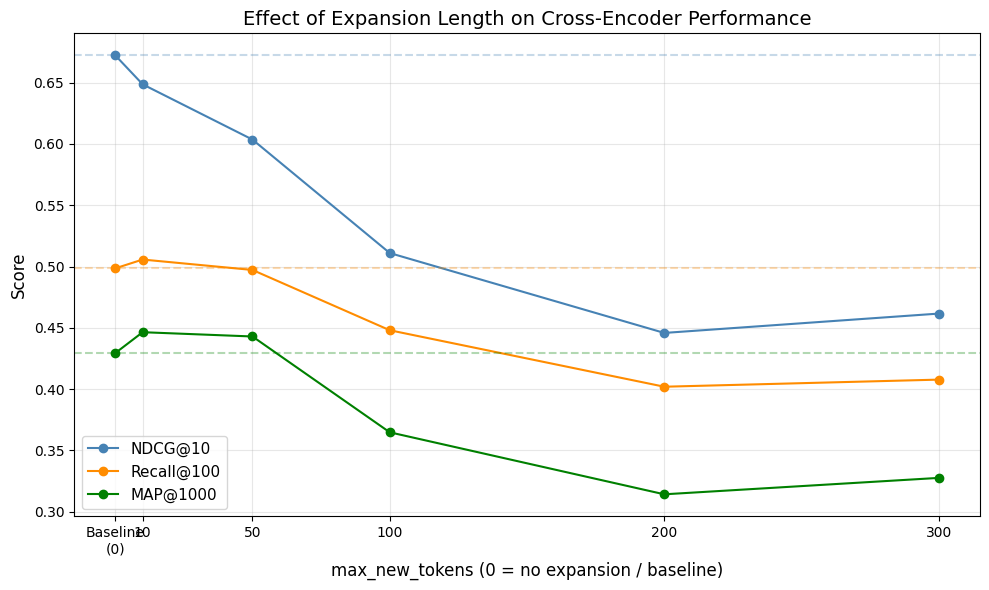


Full results:
Tokens         NDCG@10  Recall@100    MAP@1000
----------------------------------------------
Baseline        0.6724      0.4985      0.4293
10              0.6487      0.5057      0.4464
50              0.6036      0.4972      0.4429
100              0.511       0.448      0.3647
200             0.4458      0.4019      0.3141
300             0.4616      0.4077      0.3275


In [19]:
token_values = [300, 200, 100, 50, 10]

results_by_tokens = {}

for max_tokens in token_values:
    print(f"Running expansion with max_new_tokens={max_tokens}...")
    exp_queries = generate_expansions(queries, model, tokenizer, max_new_tokens=max_tokens)
    exp_scores = score_candidates(exp_queries, candidates, cross_encoder)
    results_by_tokens[max_tokens] = evaluate(exp_scores, qrels)
    print(f"  NDCG@10: {results_by_tokens[max_tokens]['ndcg_cut_10']}")

# plot
measures = ["ndcg_cut_10", "recall_100", "map_cut_1000"]
labels   = ["NDCG@10", "Recall@100", "MAP@1000"]
colors   = ["steelblue", "darkorange", "green"]

x_vals = [0] + token_values[::-1]  # 0 = baseline, then ascending token counts

fig, ax = plt.subplots(figsize=(10, 6))

for measure, label, color in zip(measures, labels, colors):
    baseline_val = original_metrics[measure]
    y_vals = [baseline_val] + [results_by_tokens[t][measure] for t in token_values[::-1]]
    ax.plot(x_vals, y_vals, marker="o", label=label, color=color)
    ax.axhline(y=baseline_val, color=color, linestyle="--", alpha=0.3)

ax.set_xlabel("max_new_tokens (0 = no expansion / baseline)", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Effect of Expansion Length on Cross-Encoder Performance", fontsize=14)
ax.set_xticks(x_vals)
ax.set_xticklabels(["Baseline\n(0)", "10", "50", "100", "200", "300"])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("expansion_length_study.png", dpi=150)
plt.show()

print("\nFull results:")
print(f"{'Tokens':<10}", end="")
for label in labels:
    print(f"{label:>12}", end="")
print()
print("-" * 46)

print(f"{'Baseline':<10}", end="")
for measure in measures:
    print(f"{original_metrics[measure]:>12}", end="")
print()

for t in token_values[::-1]:
    print(f"{t:<10}", end="")
    for measure in measures:
        print(f"{results_by_tokens[t][measure]:>12}", end="")
    print()

## Task 5: Query expansion with PRF

In [20]:
# likewise build prompt 
def build_cot_prf_prompt(query, prf_docs):
    
    context = "\n".join(prf_docs)
    return (
        f"Answer the following query based on the context:\n"
        f"Context: {context}\n"
        f"Query: {query}\n"
        f"Give the rationale before answering"
    )
    
# similarly expand queries, this time with prf
def generate_prf_expansions(queries, candidates, model, tokenizer, max_new_tokens=200, batch_size=4, n_prf_docs=3):
    expanded_queries_prf = {}
    query_ids = list(queries.keys())
    
    for i in tqdm.tqdm(range(0, len(query_ids), batch_size), desc="Expanding quries with PRF"):
        batch_ids = query_ids[i: i + batch_size]
        batch_prompts = []
        
        for query_id in batch_ids:
            # grap top-n_prf_docs from candidates
            prf_docs = [doc_text for _, doc_text in candidates[query_id][:n_prf_docs]]
            prompt = build_cot_prf_prompt(queries[query_id], prf_docs)
            batch_prompts.append(prompt)
            
        # PRF prompts are longer, so we use bigger max_length
        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True, max_length=2048).to(model.device)
        
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, temperature=1.0, repetition_penalty=1.1)
            
        for j, query_id in enumerate(batch_ids):
            input_len = inputs["input_ids"].shape[1]
            new_tokens = outputs[j][input_len:]
            expansion = tokenizer.decode(new_tokens, skip_special_tokens=True)
            
            # again filter closing phrases as per the paper
            expansion = expansion.replace("The final answer:", "").strip()
            expansion = expansion.replace("So the final answer is:", "").strip()
            
            # after running we also notice these artefacts and thus remove them
            expansion = expansion.replace("the query.", "").strip()
            expansion = expansion.replace("the query", "").strip()
            
            expanded_queries_prf[query_id] = queries[query_id] + " " + expansion
            
    return expanded_queries_prf


expanded_queries_prf = generate_prf_expansions(queries, candidates, model, tokenizer, max_new_tokens=50)

# check
sample_qid = list(expanded_queries_prf.keys())[0]
print(f"Original:     {queries[sample_qid]}")
print(f"\nExpanded PRF: {expanded_queries_prf[sample_qid]}")

Expanding quries with PRF: 100%|██████████| 11/11 [02:45<00:00, 15.09s/it]

Original:     do goldfish grow

Expanded PRF: do goldfish grow Rationale: The text mentions that goldfish grow to be no more than 1 foot long, implying that they do indeed grow. This information is provided in response to a potential question or doubt about whether goldfish grow


So the query seems to be expanded with rationale extracted from a relevant text... good

In [21]:
# sanity check
import random

sample_qids = random.sample(list(queries.keys()), 3)

for qid in sample_qids:
    print(f"{'='*70}")
    print(f"Query [{qid}]: {queries[qid]}")
    print()
    top3 = candidates[qid][:3]
    for i, (docid, doctext) in enumerate(top3, 1):
        rel = qrels.get(qid, {}).get(docid, "not in qrels")
        print(f"  PRF Doc {i} [id={docid}, relevance={rel}]:")
        print(f"  {doctext[:300]}...")
        print()

Query [489204]: right pelvic pain causes

  PRF Doc 1 [id=840379, relevance=not in qrels]:
  Chronic prostatitis, also called Chronic Pelvic Pain Syndrome (CPPS), is a common prostate problem. It can cause pain in the lower back, in the groin area, or at the tip of the penis. Men with this problem often have painful ejaculation....

  PRF Doc 2 [id=8018508, relevance=not in qrels]:
  It is sometimes referred to as a hip fracture or broken hip because it occurs in the bones that make up the hip area. A pelvic fracture causes difficulty walking or standing. It can also cause abdominal pain, bleeding from pelvic cavities, and difficulty urinating....

  PRF Doc 3 [id=5171357, relevance=not in qrels]:
  How is ultrasound used in women’s health care? Ultrasound can be used to diagnose and monitor certain problems, such as a pelvic mass, a breast lump, abnormal bleeding, pelvic pain, or infertility. It also can be used during pregnancy to monitor the fetus....

Query [87181]: causes of left 

But if we inspect other queries at random, we see that the 3 documents are not always relevant. For example

Query [146187]: difference between a mcdouble and a double cheeseburger

There is one slighly relevant document, and other two mention something about double, but in no shape or form reflect anything about cheeseburgers.

For Query [156493]: do goldfish grow 

One document is highly relevant, and as seen in the above cell, is what the answer was mostly driven upon, other two merely mention goldfishes but nothing about growing.


### So these documents can be noisy and misleading!

In [22]:
qid = list(queries.keys())[3]
print(f"Query: {queries[qid]}")
print(f"Total candidates: {len(candidates[qid])}")
print()
for i, (docid, doctext) in enumerate(candidates[qid][:5], 1):
    rel = qrels.get(qid, {}).get(docid, "not judged")
    print(f"Position {i} [relevance={rel}]: {doctext[:150]}...")
    print()

Query: definition declaratory judgment
Total candidates: 1000

Position 1 [relevance=not judged]: If you do not pay the judgment, the judge can order you to appear in court. This is called an Application And Order For Appearance and Examination (EJ...

Position 2 [relevance=not judged]: If you win a lawsuit for money, you will get a copy of the Court's judgment stating the. amount of money the losing party must pay to you. The losing ...

Position 3 [relevance=not judged]: (a) A judgment may be revived in the seventh year after its entry, or in the seventh year after its last revival, or at any other time thereafter with...

Position 4 [relevance=not judged]: A judgment is an automatic lien on real property owned by the defendant in the county in which the judgment is located. The lien of a judgment lasts f...

Position 5 [relevance=not judged]: Information & Instructions: Post judgment discovery. 1. The purpose of Post judgment discovery, either by deposition or interrogatories, is to

As we see above, the candidates which we take first 3 of, well they are not even judged on relevance... this can mess with the results. Lets see

In [23]:
# now for scoring and evaluating we can reuse same functions

prf_scores = score_candidates(expanded_queries_prf, candidates, cross_encoder)
prf_metrics = evaluate(prf_scores, qrels)

# full comparison table
print(f"\n{'Metric':<20} {'Original':>10}  {'CoT (50)':>10} {'CoT/PRF (50)':>13}")
print("-" * 57)
for measure in ["ndcg_cut_10", "recall_100", "map_cut_1000"]:
    orig = original_metrics[measure]
    exp50 = expanded_metrics_short[measure]
    prf = prf_metrics[measure]
    print(f"{measure:<20} {orig:>10} {exp50:>10} {prf:>13}")

Scoring: 100%|██████████| 43/43 [00:14<00:00,  3.05it/s]


Metric                 Original    CoT (50)  CoT/PRF (50)
---------------------------------------------------------
ndcg_cut_10              0.6724     0.6036        0.5363
recall_100               0.4985     0.4972        0.4737
map_cut_1000             0.4293     0.4429        0.4047


Indeed, CoT/PRF is performing worst...

### We suspect that these expansions can add to much noise and take up valuable tokens which are limited in the cross encoder

In [24]:
# motivated by our finding that shorter expansions perform better.
# we test two minimal prompts: keywords-only.

def build_keywords_prompt(query):
    """Keywords-only prompt — generates compact expansion terms with no filler.
    Contrast to CoT which generates verbose rationale."""
    return f"Write a short list of keywords for the given query: {query}"


# can define similar prompts

custom_prompts = {
    "keywords": build_keywords_prompt,
    # and add them here
}

custom_results = {}

for prompt_name, prompt_fn in custom_prompts.items():
    print(f"\nRunning: {prompt_name}")
    exp_queries = generate_expansions(queries, model, tokenizer,
                                      max_new_tokens=50,
                                      prompt_fn=prompt_fn)
    exp_scores  = score_candidates(exp_queries, candidates, cross_encoder)
    custom_results[prompt_name] = evaluate(exp_scores, qrels)


print(f"\n{'Metric':<20} {'Original':>10} {'Keywords':>10}")
print("-" * 62)
for measure in ["ndcg_cut_10", "recall_100", "map_cut_1000"]:
    orig     = original_metrics[measure]
    keywords = custom_results["keywords"][measure]
    # and here
    print(f"{measure:<20} {orig:>10} {keywords:>10} ") # in here


Running: keywords


Scoring: 100%|██████████| 43/43 [00:14<00:00,  2.89it/s]


Metric                 Original   Keywords
--------------------------------------------------------------
ndcg_cut_10              0.6724     0.5464 
recall_100               0.4985     0.4825 
map_cut_1000             0.4293     0.3926 


That is an improvement, but lastly, mayhaps 50 tokens is still to long. Lets compare are with maximum expansion of 20 tokens

In [25]:
expanded_queries_keywords_20 = generate_expansions(queries, model, tokenizer, max_new_tokens=20,prompt_fn=build_keywords_prompt)
expanded_queries_cot_20 = generate_expansions(queries, model, tokenizer, max_new_tokens=20)
expanded_queries_prf_20 = generate_prf_expansions(queries, candidates, model, tokenizer, max_new_tokens=20)

scores_cot_20      = score_candidates(expanded_queries_cot_20,      candidates, cross_encoder)
scores_prf_20      = score_candidates(expanded_queries_prf_20,       candidates, cross_encoder)
scores_keywords_20 = score_candidates(expanded_queries_keywords_20,  candidates, cross_encoder)

metrics_cot_20      = evaluate(scores_cot_20,      qrels)
metrics_prf_20      = evaluate(scores_prf_20,       qrels)
metrics_keywords_20 = evaluate(scores_keywords_20,  qrels)

all_results = {
    "Original (no expansion)": original_metrics,
    "CoT (20 tokens)":         metrics_cot_20,
    "CoT/PRF (20 tokens)":     metrics_prf_20,
    "Keywords (20 tokens)":    metrics_keywords_20,

}

print(f"{'Setting':<30} {'NDCG@10':>10} {'Recall@100':>12} {'MAP@1000':>10}")
print("-" * 65)
for name, metrics in all_results.items():
    ndcg  = metrics["ndcg_cut_10"]
    rec   = metrics["recall_100"]
    mp    = metrics["map_cut_1000"]
    print(f"{name:<30} {ndcg:>10} {rec:>12} {mp:>10}")

Scoring: 100%|██████████| 43/43 [00:14<00:00,  3.07it/s]

Setting                           NDCG@10   Recall@100   MAP@1000
-----------------------------------------------------------------
Original (no expansion)            0.6724       0.4985     0.4293
CoT (20 tokens)                    0.6245       0.5084     0.4517
CoT/PRF (20 tokens)                0.5594       0.4725     0.4092
Keywords (20 tokens)               0.6222       0.5098      0.439


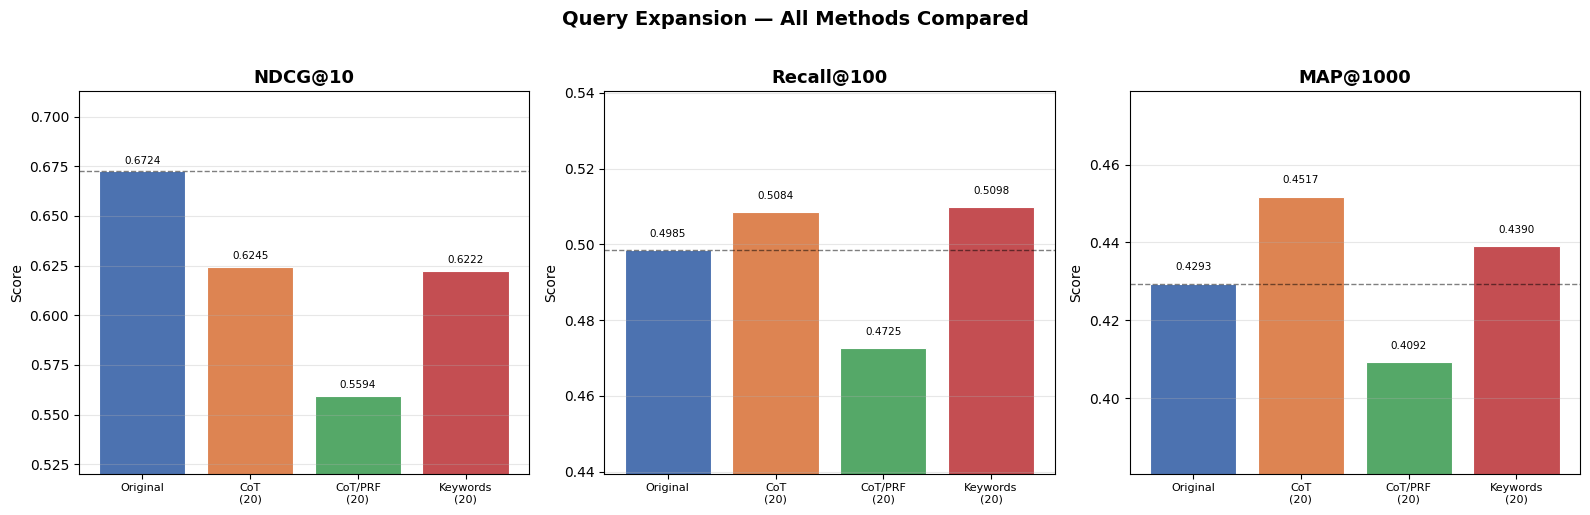

In [26]:
labels  = list(all_results.keys())
metrics_to_plot = ["ndcg_cut_10", "recall_100", "map_cut_1000"]
metric_labels   = ["NDCG@10", "Recall@100", "MAP@1000"]

short_labels = [
    "Original",  "CoT\n(20)", 
    "CoT/PRF\n(20)", "Keywords\n(20)",
]

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, measure, title in zip(axes, metrics_to_plot, metric_labels):
    values   = [all_results[name][measure] for name in labels]
    baseline = values[0]
    bars     = ax.bar(short_labels, values, color=colors, edgecolor="white", linewidth=0.8)

    # baseline reference line
    ax.axhline(y=baseline, color="black", linestyle="--", linewidth=1, alpha=0.5, label="Baseline")

    # value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{val:.4f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(min(values) * 0.93, max(values) * 1.06)
    ax.set_ylabel("Score", fontsize=10)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Query Expansion — All Methods Compared", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("expansion_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# COMMANDS TO CONVERT TO .py AND GENERATE requirements.txt  # NEEDS pipreqs INSTALLED
# !jupyter nbconvert --to script IR_code.ipynb
# !pipreqs . --force